# 71 - Code Challenge: Parameterising a CNN

**Section:** CNNs | **Prereqs:** `CNNs/Examining_Feature_Maps.ipynb` | **Next:** `CNNs/CodeChallenge_VaryingNumber_of_Channels.ipynb`

Hardcoded channel counts make a model impossible to sweep. Take one width
parameter `n` and derive the rest from it (`n`, `2n`, `4n`), and the whole
architecture becomes a single number you can put in a loop.

**Also demonstrated: non-square kernels and strides.** `kernel_size=(3,2)` and
`stride=(2,3)` are legal - the two spatial dimensions are independent. Rarely
useful for photographs, where structure is isotropic, but natural for
spectrograms and time-frequency data, where the two axes mean different things.

**Why `AdaptiveAvgPool2d((1,1))` is what makes this work.** With asymmetric
strides the spatial size after the conv stack is awkward to compute by hand, and
it changes with `n`... except it does not, because adaptive pooling forces it to
1x1 regardless. The flatten size is then exactly `4n`, known without arithmetic.
Without it, every value of `n` would need its own hand-computed `Linear` size.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split

import torchsummary

In [2]:
# The synthetic dataset for this notebook: 2-D Gaussian blobs at random centres,
# with one of two widths (sigma = 1.8 or 2.4), plus noise.
# The label is which sigma was used - i.e. the task is 'is this blob wide or
# narrow', which is position-independent by construction. Perfect for a CNN, and
# nearly impossible for an FNN, which would have to learn it separately at every
# location.
# 20000 images here - a large synthetic dataset, since generating it is cheap.
img_size = 91
n_perClass = 10000

sigma = [1.8,2.4]


x = np.linspace(-4,4,img_size)

X,Y = np.meshgrid(x,x)


images = np.zeros((2*n_perClass , 1, img_size,img_size), dtype=float)
labels = np.zeros(2*n_perClass)

for i in range(2*n_perClass):

  center = 2*np.random.randn(2)

  X_hat = X - center[0]
  Y_hat = Y - center[1]

  G = np.exp(-(X_hat ** 2 + Y_hat**2) / (2*sigma[i%2]))

  noise = np.random.randn(*G.shape) / 5

  images[i,:,:,:] = G - noise
  labels[i] = i%2


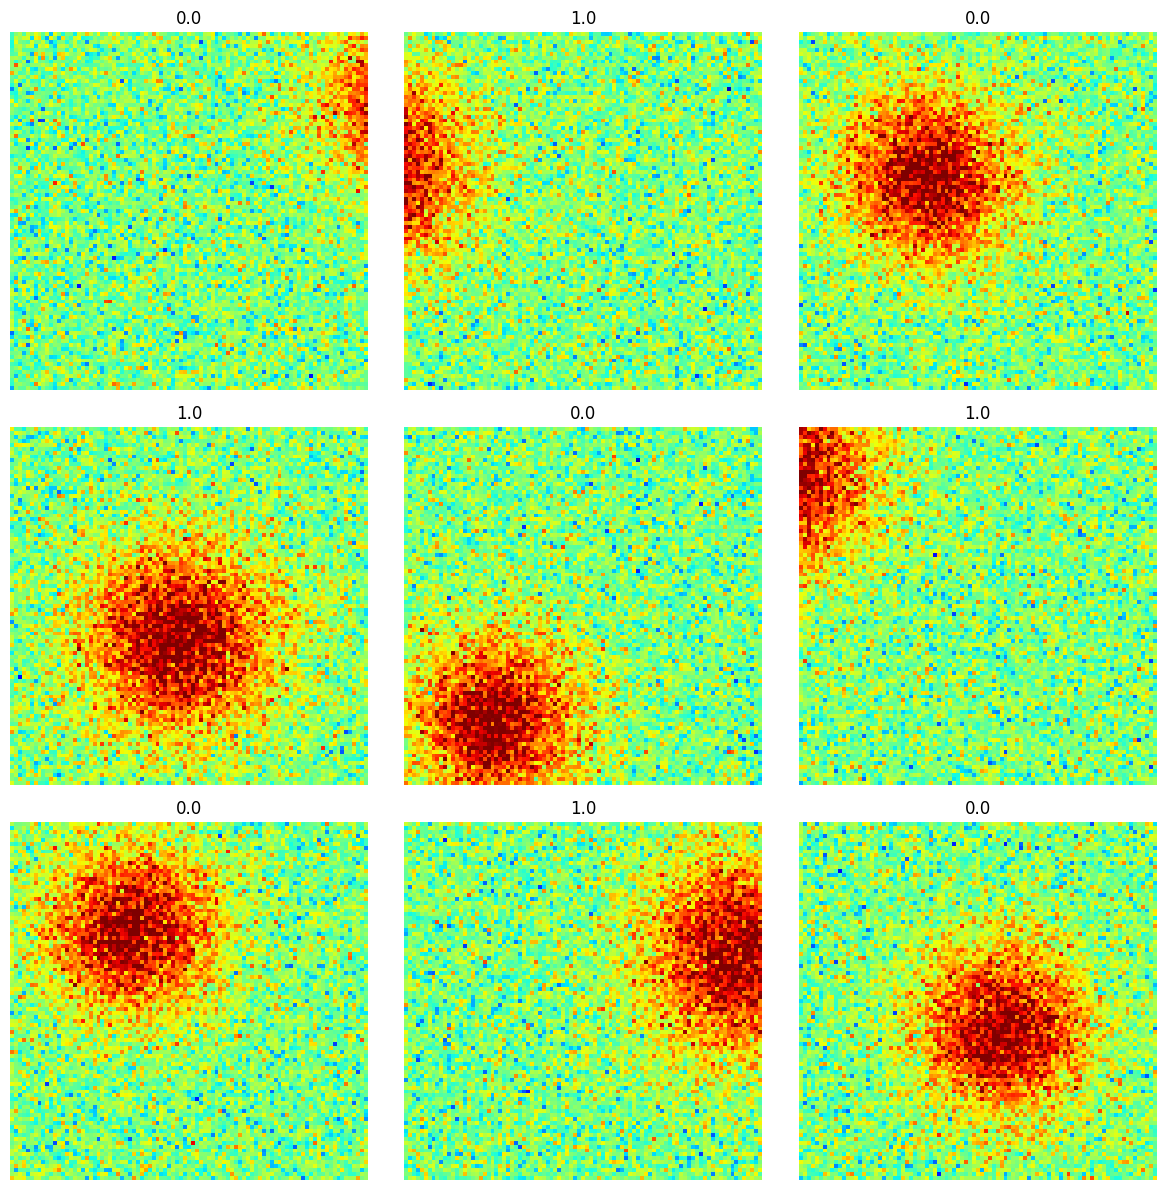

In [3]:
# Sample images from both classes.
fig, ax = plt.subplots(3,3, figsize=(12,12))
ax = ax.flatten()


for i in range(min(2*n_perClass, len(ax))):
  ax[i].imshow(np.squeeze(images[i]), vmin=-1, vmax=1, cmap='jet')
  ax[i].set_title(str(labels[i].item()));
  ax[i].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# Split and loaders.
# Data Loader

device = ('cuda' if torch.cuda.is_available() else 'cpu')
train_data, test_data, train_label, test_label = train_test_split(images, labels, test_size=0.10)

train_tensor = torch.tensor(train_data, dtype=torch.float , device=device)
train_label = torch.tensor(train_label, dtype=torch.long, device=device)

test_tensor = torch.tensor(test_data, dtype=torch.float , device=device)
test_label = torch.tensor(test_label, dtype=torch.long, device=device)

train_dataset = TensorDataset(train_tensor, train_label)
test_dataset = TensorDataset(test_tensor , test_label)

bs = 8
train_loader = DataLoader(train_dataset ,batch_size=bs , drop_last=True, shuffle=True)
test_loder = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

In [5]:
# The parameterised model. Channels are n -> 2n -> 4n, so one argument sets the
# whole width.
# Non-square kernel (3,2) and stride (2,3): the height and width dimensions are
# treated independently. Legal, occasionally useful (spectrograms), and here
# mostly a demonstration.
# AdaptiveAvgPool2d((1,1)) is what makes the design work: whatever awkward
# spatial size the asymmetric strides produce, it becomes 1x1, so the Linear
# layer's input is exactly 4n and needs no hand computation.
class BlurModel(nn.Module):
  def __init__(self, n):
    super().__init__()

    self.conv = nn.Sequential(
        nn.Conv2d(1,n,stride=(2,3),padding=1,kernel_size=(3,2)),
        nn.ReLU(),
        nn.MaxPool2d((2,2)),

        nn.Conv2d(n,2*n, stride=(2,3), padding=1, kernel_size=(3,2)),
        nn.ReLU(),
        nn.MaxPool2d((2,2)),

        nn.Conv2d(2*n,4*n,stride=(2,3), padding=1, kernel_size=(3,2)),
        nn.ReLU(),
        nn.MaxPool2d((2,2)),

        nn.AdaptiveAvgPool2d((1,1))
    )

    self.fc1 = nn.Linear(4*n,2*n)
    self.out = nn.Linear(2*n,1)


  def forward(self,x):

    x = self.conv(x)

    x = x.view(x.size(0), -1)

    x = F.relu(self.fc1(x))

    return self.out(x)


In [6]:
# A wide instance (n=128) to check it builds.
test_model = BlurModel(128)
test_model.to(device)

BlurModel(
  (conv): Sequential(
    (0): Conv2d(1, 128, kernel_size=(3, 2), stride=(2, 3), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(128, 256, kernel_size=(3, 2), stride=(2, 3), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 512, kernel_size=(3, 2), stride=(2, 3), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (9): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (fc1): Linear(in_features=512, out_features=256, bias=True)
  (out): Linear(in_features=256, out_features=1, bias=True)
)

In [7]:
# torchsummary - watch how the spatial dimensions shrink unevenly because of the
# asymmetric strides.
torchsummary.summary(test_model, input_size=(1,91,91))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 128, 46, 31]             896
              ReLU-2          [-1, 128, 46, 31]               0
         MaxPool2d-3          [-1, 128, 23, 15]               0
            Conv2d-4           [-1, 256, 12, 6]         196,864
              ReLU-5           [-1, 256, 12, 6]               0
         MaxPool2d-6            [-1, 256, 6, 3]               0
            Conv2d-7            [-1, 512, 3, 2]         786,944
              ReLU-8            [-1, 512, 3, 2]               0
         MaxPool2d-9            [-1, 512, 1, 1]               0
AdaptiveAvgPool2d-10            [-1, 512, 1, 1]               0
           Linear-11                  [-1, 256]         131,328
           Linear-12                    [-1, 1]             257
Total params: 1,116,289
Trainable params: 1,116,289
Non-trainable params: 0
---------------------------

In [8]:
# Training function taking n, ready to be swept.
# Note the threshold here is `yhat > 0`, the correct one for BCEWithLogitsLoss.
def train_model(n: int):

  model = BlurModel(n).to(device)

  lr = 1e-3
  epochs = 50

  lossFunc = nn.BCEWithLogitsLoss()
  optimizer = torch.optim.Adam(model.parameters(),lr=lr)

  losses = []
  train_acc = []
  val_acc = []

  for epoch in range(epochs):

    model.train()

    batch_acc = []
    batch_loss = []

    for x,y in train_loader:

      yhat = model(x)

      loss = lossFunc(yhat, y.unsqueeze(1).float())
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(100 * torch.mean( ((yhat > 0) == y.float().unsqueeze(1)).float().detach().cpu()).item())

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))


    # Now Validation

    model.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loder))
      val_acc.append(100 * torch.mean( ((model(X) > 0) == Y.float().unsqueeze(1)).float().detach().cpu()).item())

    if epoch % 5 == 0 or epoch == epochs - 1:
      print(f'Epoch : {epoch} | loss : {losses[epoch]:.2f} | train_acc : {train_acc[epoch]:.2f}  | Val Acc : {val_acc[epoch]:.2f}')

  return model, losses, train_acc, val_acc

In [9]:
x = torch.randn(1000,1)
x.size()

torch.Size([1000, 1])

In [10]:
# One run at n=32.
model, losses, train_acc, val_acc = train_model(32)

Epoch : 0 | loss : 0.57 | train_acc : 68.43  | Val Acc : 78.35
Epoch : 5 | loss : 0.30 | train_acc : 84.52  | Val Acc : 80.35
Epoch : 10 | loss : 0.26 | train_acc : 86.79  | Val Acc : 83.65
Epoch : 15 | loss : 0.22 | train_acc : 89.01  | Val Acc : 81.80
Epoch : 20 | loss : 0.20 | train_acc : 90.12  | Val Acc : 88.30
Epoch : 25 | loss : 0.18 | train_acc : 91.51  | Val Acc : 90.45
Epoch : 30 | loss : 0.16 | train_acc : 92.48  | Val Acc : 87.60
Epoch : 35 | loss : 0.15 | train_acc : 93.16  | Val Acc : 86.40
Epoch : 40 | loss : 0.14 | train_acc : 93.51  | Val Acc : 88.05
Epoch : 45 | loss : 0.13 | train_acc : 94.12  | Val Acc : 87.95
Epoch : 49 | loss : 0.12 | train_acc : 94.86  | Val Acc : 89.00


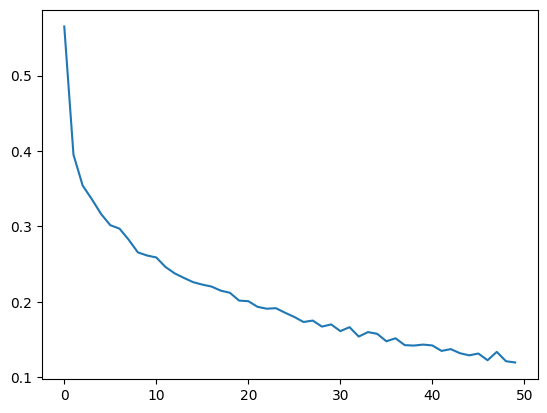

In [11]:
# Loss curve.
plt.plot(losses);

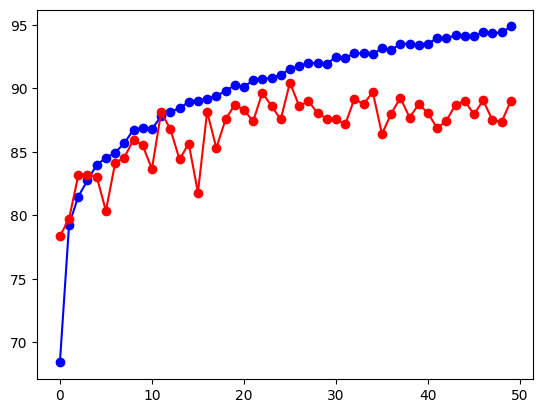

In [12]:
# Train and validation accuracy. The architecture is now a single number away
# from a full sweep - which is the next notebook.
plt.plot(train_acc, 'bo-')
plt.plot(val_acc, 'ro-');